# Movie Recommendation System

## Objective

A Movie Recommendation System suggests movies to users based on movie content and similarities.

This project uses:

- Content-Based Filtering
- TF-IDF Vectorization
- Cosine Similarity

The system recommends movies similar to the selected movie.

In [14]:
# Import Required Libraries

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

## Load Dataset

In [15]:
# Read Dataset

df = pd.read_csv("movies.csv")

df.head()

,id,title,genre,original_language,overview,popularity,release_date,vote_average,vote_count
0,278,The Shawshank Redemption,"Drama,Crime",en,Framed in the 1940s for the double murder of h...,94.075,1994-09-23,8.7,21862
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,Romance",hi,"Raj is a rich, carefree, happy-go-lucky second...",25.408,1995-10-19,8.7,3731
2,238,The Godfather,"Drama,Crime",en,"Spanning the years 1945 to 1955, a chronicle o...",90.585,1972-03-14,8.7,16280
3,424,Schindler's List,"Drama,History,War",en,The true story of how businessman Oskar Schind...,44.761,1993-12-15,8.6,12959
4,240,The Godfather: Part II,"Drama,Crime",en,In the continuing saga of the Corleone crime f...,57.749,1974-12-20,8.6,9811


## Dataset Information

In [16]:
# Dataset Shape

print("Dataset Shape :", df.shape)

# Column Names

print(df.columns)

Dataset Shape : (10000, 9)
Index(['id', 'title', 'genre', 'original_language', 'overview', 'popularity',
       'release_date', 'vote_average', 'vote_count'],
      dtype='object')


In [17]:
# Missing Values

df.isnull().sum()

id                    0
title                 0
genre                 3
original_language     0
overview             13
popularity            0
release_date          0
vote_average          0
vote_count            0
dtype: int64

## Select Important Features

In [18]:
features = [
    "genre",
    "overview"
]

for feature in features:
    df[feature] = df[feature].fillna("")

## Combine Features

In [19]:
df["combined_features"] = (
    df["genre"] +
    " " +
    df["overview"]
)

df["combined_features"].head()

0    Drama,Crime Framed in the 1940s for the double...
1    Comedy,Drama,Romance Raj is a rich, carefree, ...
2    Drama,Crime Spanning the years 1945 to 1955, a...
3    Drama,History,War The true story of how busine...
4    Drama,Crime In the continuing saga of the Corl...
Name: combined_features, dtype: object

## Convert Text into Numerical Features

In [20]:
vectorizer = TfidfVectorizer(
    stop_words="english"
)

feature_vectors = vectorizer.fit_transform(
    df["combined_features"]
)

print(feature_vectors.shape)

(10000, 27965)


## Calculate Similarity Matrix

In [21]:
similarity = cosine_similarity(
    feature_vectors
)

similarity.shape

(10000, 10000)

## Create Recommendation Function

In [22]:
def recommend_movies(movie_name):

    movie_index = df[
        df["title"] == movie_name
    ].index[0]

    similarity_scores = list(
        enumerate(
            similarity[movie_index]
        )
    )

    sorted_movies = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    print("\nRecommended Movies:\n")

    for movie in sorted_movies[1:11]:

        index = movie[0]

        print(
            df.iloc[index]["title"]
        )

## Test Recommendation System

In [23]:
recommend_movies(
    "The Godfather"
)


Recommended Movies:

The Godfather: Part II
The Godfather: Part III
Blood Ties
Proud Mary
The Best of Youth
Bar Sport
Four Brothers
Joe
Xtreme
Rampart


In [24]:
recommend_movies(
    "The Shawshank Redemption"
)


Recommended Movies:

In Hell
Brubaker
Sherlock Jr.
Demolition
Escape Plan
The Chorus
The 40 Year Old Virgin
One Shot
Cool Hand Luke
Fatal Attraction


## Popular Movies Analysis

In [25]:
top_movies = df.sort_values(
    by="vote_average",
    ascending=False
)

top_movies[
    ["title","vote_average"]
].head(10)

,title,vote_average
0,The Shawshank Redemption,8.7
2,The Godfather,8.7
1,Dilwale Dulhania Le Jayenge,8.7
3,Schindler's List,8.6
4,The Godfather: Part II,8.6
5,Impossible Things,8.6
16,"The Good, the Bad and the Ugly",8.5
26,Once Upon a Time in America,8.5
25,Life Is Beautiful,8.5
24,Violet Evergarden: The Movie,8.5


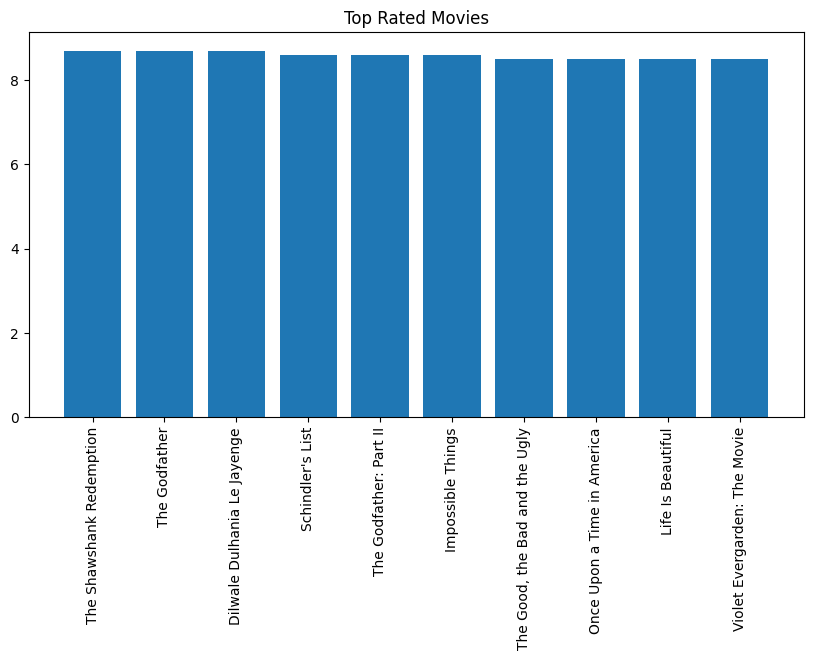

In [26]:
import matplotlib.pyplot as plt

top10 = top_movies.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["title"],
    top10["vote_average"]
)

plt.xticks(rotation=90)

plt.title(
    "Top Rated Movies"
)

plt.show()

# Conclusion

The Movie Recommendation System successfully recommends similar movies using content-based filtering.

Machine Learning Techniques Used:

- TF-IDF Vectorization
- Cosine Similarity

Features Used:

- Genre
- Movie Overview

The system helps users discover movies that match their interests and preferences.